# Progetto fine modulo

0_Importazione librerie

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, KFold, learning_curve
from pandas.plotting import scatter_matrix

1 Data Exploration & Preprocessing

In [13]:
# caricamento dataset diabetes e visualizzazione delle caratteristiche principali

data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = X.copy()
df["target"] = y
display(df)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


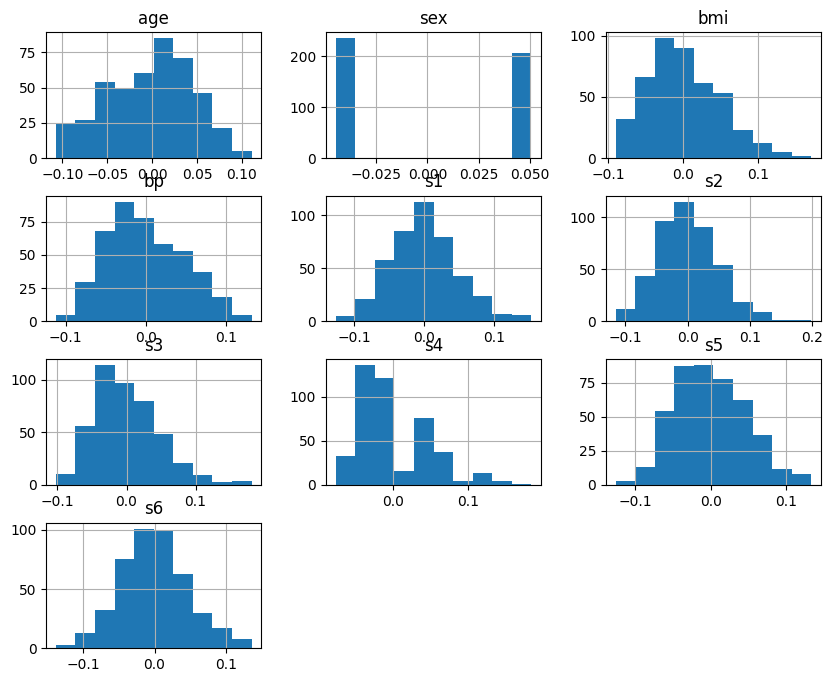

In [21]:
# visiualizzazione con strumenti grafici: istogramma

X.hist(figsize=(10,8))
plt.show()

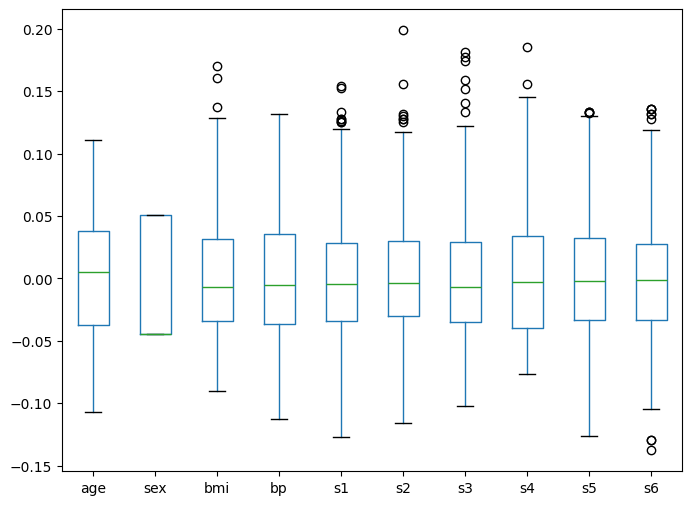

In [22]:
# visiualizzazione con strumenti grafici: boxplot

X.boxplot(figsize=(8,6), grid=False)
plt.show()

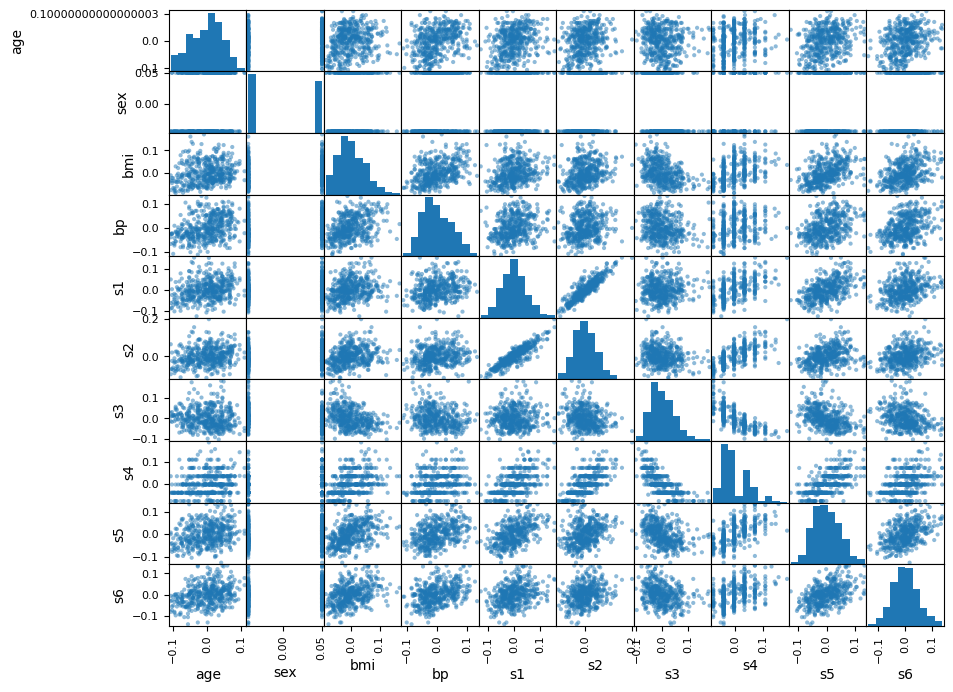

In [ ]:
# visiualizzazione con strumenti grafici: scatter matrix

scatter_matrix(X, figsize=(10,8))
plt.show()

Commento delle feature sulla base dell'analisi dei grafici

È stato scelto solo il dataset contente le feature, poiché l’inclusione del target introduceva una variabile con scala e significato diverso rispetto alle feature, rendendo più complessa l'analisi visiva
Dall'analisi dell'istogramma emerge che:
- la variabile "bmi" ha una distribuzione gaussiana (non normale standard), con la media leggermente spostata; 
- la variabile "s4" presenta una distribuzione trimodale;
- la variabile "sex" è una feature binaria;
- anche le altre feature sembrano avere una distribuzioni approssimativamente simmetriche o già standardizzate, ma anche queste presentano diversi picchi o media spostata a destra o sinistra.
Dall'analisi del boxplot emerge che: 
- le feature "bmi" e "bp" presentano pochi outlier rispetto al loro tipo
Dall'analisi della scatter matrix emerge che:
- la coppia migliore (più correlata) sembra essere quella composta dalle feature "s1" e "s2"; 
- nel complesso anche bmi ha una buona correlazione con tutte le altre feature;
- la feature "s4" mostra delle relazioni molto meno evidenti con le altre feature;
- in generale le feature risultano correllate tra loro, indicando un buon utilizzo per le stesse nei prossimi step analitici

In [27]:
# preparazione dei dati in train e test con il data splitting e scaling dei dati

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=0.20,
    random_state=42
)

# scaling dei dati

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2 Confronto e Selezione Iniziale dei Modelli

In [28]:
# implementazione della regressione standard utilizzando i seguenti modelli: regressione lineare, ridge, lasso, knn, decision tree e svm

models = [
    ("Regressione Lineare", LinearRegression()),
    ("Regressione Ridge", Ridge(alpha=0.1)),
    ("Regressione Lasso", Lasso(alpha=0.1, max_iter=1000)),
    ("K-nn", KNeighborsRegressor(n_neighbors=3)),
    ("Decision Tree", DecisionTreeRegressor(max_depth=3, random_state=42)),
    ("SVM", SVR(kernel='linear', C=1.0, epsilon=0.1))
]

In [33]:
# andiamo a calcolare gli score per vedere qual è il modello migliore con parametri default basando il confronto sulla Negative Mean Squared Error 

names = []
results = []

K = 10
for name, model in models:
    kfold = KFold(n_splits=K, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring="neg_mean_squared_error")
    names.append(name)
    results.append(cv_results)
    print(f"{name}:\n\tMEAN:\t{cv_results.mean():.4f}\n\tSTD:\t{cv_results.std():.4f}")

Regressione Lineare:
	MEAN:	-3067.3095
	STD:	548.7667
Regressione Ridge:
	MEAN:	-3066.8739
	STD:	549.2249
Regressione Lasso:
	MEAN:	-3066.0161
	STD:	552.9855
K-nn:
	MEAN:	-4249.0568
	STD:	924.8770
Decision Tree:
	MEAN:	-4078.4564
	STD:	900.5527
SVM:
	MEAN:	-3123.3865
	STD:	621.7142


Dall'analisi dei modelli si evince come i modelli lineari di regressione (lineare, ridge e lasso), mostrano numeri molto simili e sembrano essere i migliori sia in termini di media che di varianza. I modelli peggiori per l'analisi risultano essere il Decision Tree e il k-nn, probabilmente a causa della distanza tra le feature non ottimale per il k-nn (si potrebbe utilizzare la PCA per i modelli sensibili alla distanza come il k-nn) e per le relazioni che non lo rendono molto utilizzabile con i decision tree. Il SVM, invece, presenta una buona media ma una deviazione standard più alta rispetto ai modelli lineari. 

In sintesi, il modello che ho scelto di usare per la grid search è Lasso, perché presenta la media più vicina a 0 di tutti e andrò ad esplorare come cambia con l'alpha ottimale 

3_Hyperparameters Tuning

In [35]:
# grid search sul lasso per calcolare l'iperparametro cruciale: alpha

param_grid = {
    "alpha": [0.1, 0.5, 1.0, 5.0, 10.0],
}

grid = GridSearchCV(Lasso(), param_grid=param_grid, cv=5, scoring="neg_mean_squared_error")
grid.fit(X_train_scaled, y_train)

best_lasso = grid.best_estimator_
y_pred_best = best_lasso.predict(X_test_scaled)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Parametri migliori:\n{grid.best_params_}")
print(f"MSE_best:\t{mse_best:.4f}")

Parametri migliori:
{'alpha': 1.0}
MSE_best:	2824.5681


4_Analisi delle performance

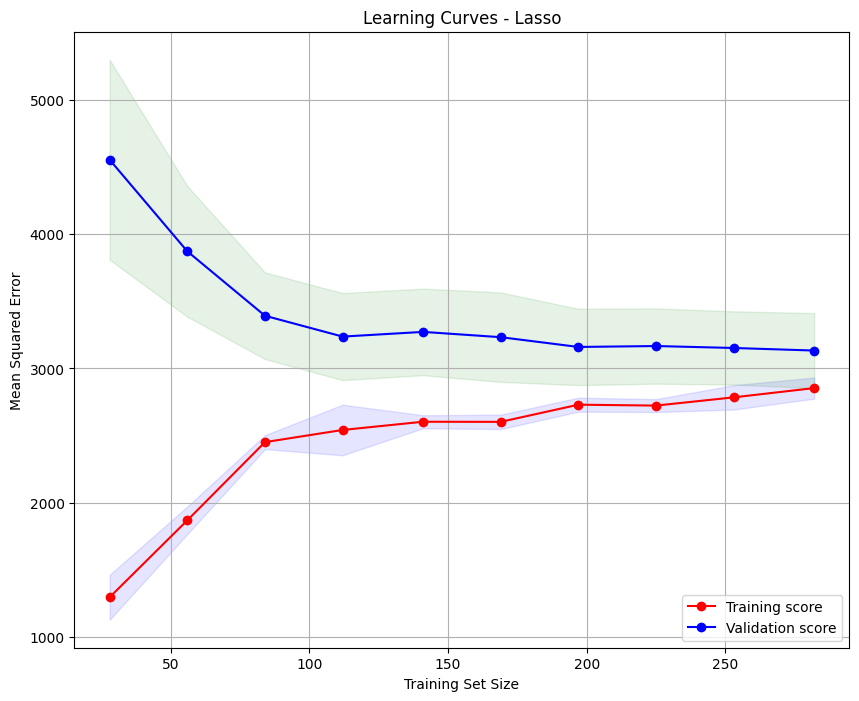

In [38]:
# Learning Curves con il modello ottimizzato

train_sizes, train_scores, val_scores = learning_curve(
    best_lasso, 
    X_train_scaled,
    y_train,
    cv=5,
    n_jobs=-1,
    scoring="neg_mean_squared_error",
    train_sizes = np.linspace(0.1, 1.0, 10)
) 

train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis = 1)
val_mean = -np.mean(val_scores, axis =1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize = (10,8))
plt.plot(train_sizes, train_mean, "o-", color="red", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_mean, "o-", color="blue", label="Validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='green')
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curves - Lasso")
plt.legend(loc='lower right')
plt.grid()
plt.show()

Analisi dello score per le learning curves

L'analisi delle learning curves mostrano un buon equilibrio, in quanto il validation score è molto alto all'inizio e diminuisce all'aumentare delle osservazioni, tendendo poi a stabilizzarsi; mentre il training score è inizialmente basso e poi si alza con l'aumentare del dataset. La distanza tra le curve inizia a ridursi e le due curve si avvicinano, ma non convergono. Questo indica un buon equilibrio tra bias e varianza e una leggera tendenza all'underfitting; tuttavia il risultato è stabile, ma è limitato dal fatto che il Lasso è un modello lineare. 

5_Visualizzazione con data reduction

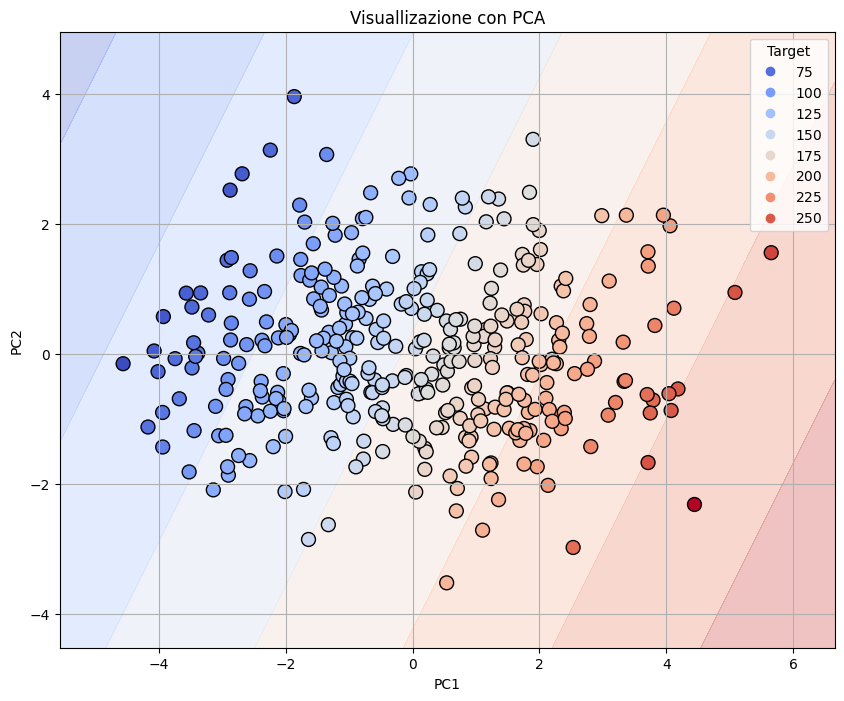

In [48]:
# applicazione PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
best_lasso.fit(X_pca, y_train)
y_pred_best = best_lasso.predict(X_pca)

# creazione griglia
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = best_lasso.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# creazione grafico
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_best, cmap="coolwarm", edgecolors="k", s=100)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visuallizazione con PCA"),
plt.legend(*scatter.legend_elements(), title="Target")
plt.grid(True)
plt.show()